# Creating a basic Chatbot in Langgraph with concept of persistence



In [1]:
from langgraph.graph import StateGraph, START , END
from typing import List, TypedDict, Annotated 
from langchain_core.messages import HumanMessage , AIMessage, SystemMessage, BaseMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

## We have to first create a shared state that any node of our graph can make changes to , here it is ChatState 
- We also need to use a reducer function so that multiple nodes would not overwrite on each other's response 
- By default the nature of state is defined in a manner that it completely replaces prev value of state and directly replaces it 
- A basic Reducer function plays the role of simply appending the message in this case however there are complex reducer functions as well we will use a built in Reducer function designed for appending prompts , this class is avialable in langgraph only
- we will use a list of BaseMessage
BaseMessage Class of Langchain can have any kind of message be it system , ai or human

In [2]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage],add_messages]

In [3]:
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
)

In [4]:
def chat_node(state: ChatState)->ChatState:
    # Take user input 
    message = state["messages"]
    # send to llm 
    response= llm.invoke(message)
    # response store state
    return {
        "messages" :[response]
    }

# Introuducing the concept of Checkpointer

In [5]:
checkpointer = MemorySaver()


graph = StateGraph(ChatState)
graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot= graph.compile(checkpointer=checkpointer)

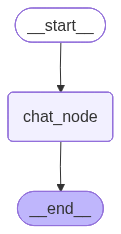

In [6]:
chatbot

In [ ]:
initial_state={
    'messages': [HumanMessage(content="Write me blog around LLM Evals")]
}
#conversation = chatbot.invoke(initial_state)

In [ ]:
#conversation['messages'][-1].content

'**Title: Evaluating the Giants: The Crucial Role of LLM Evaluations in AI Development**\n\n**Introduction**  \nIn the rapidly evolving world of artificial intelligence, Large Language Models (LLMs) like GPT, BERT, and others have become cornerstones of innovation. From powering chatbots to generating creative content, their applications are vast. However, with great power comes great responsibility. Ensuring these models perform reliably, ethically, and effectively requires rigorous evaluation. In this blog, we explore the importance of LLM evaluations, the methods used, and the challenges that come with assessing these complex systems.\n\n---\n\n### **Why LLM Evaluations Matter**  \nLLMs are trained on massive datasets and can perform a wide range of tasks, from answering questions to writing code. But how do we know if they’re doing a good job? Evaluations serve as the "report card" for these models, helping developers:  \n- **Measure Performance**: Quantify how well a model excels 

In [7]:
thread = '1'
while True:
    user_message = input("Type here : ")
    print("you : ",user_message)
    if user_message.strip().lower() in ["exit","quit","end","bye"]:
        break
    config= {"configurable":{'thread_id':thread}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print("AI : ", response['messages'][-1].content)


you :  hi my name is moksh
AI :  Hi Moksh! Nice to meet you! 😊 How can I assist you today?
you :  whats my name?
AI :  Your name is **Moksh**! 😊 How can I assist you today, Moksh?
you :  exit


In [8]:
config

{'configurable': {'thread_id': '1'}}

In [9]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is moksh', additional_kwargs={}, response_metadata={}, id='57287bbe-fd5d-4943-b80e-75b1aed2f7f6'), AIMessage(content='Hi Moksh! Nice to meet you! 😊 How can I assist you today?', additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Moksh. I should acknowledge their name and respond warmly. Let me make sure to use their name in the response to create a personal connection. I'll ask how I can assist them today to keep the conversation open. Keeping it friendly and approachable is key here. No need for any complex language or structure. Just a simple, welcoming reply.\n"}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 15, 'total_tokens': 117, 'completion_time': 0.204290938, 'completion_tokens_details': {'reasoning_tokens': 78}, 'prompt_time': 0.000457891, 'prompt_tokens_details': None, 'queue_time': 0.159773147, 'total_time': 0.204748829}, 'model_name': 'qwen/qwen